# Bluestock Mutual Fund - Comprehensive Exploratory Data Analysis (EDA)
**Prepared for**: Investment Committee & Product Strategy Team  
**Analysis Period**: 2022 - 2026  

This notebook performs a deep-dive Exploratory Data Analysis (EDA) on Bluestock Mutual Fund data to uncover key insights regarding:
1. **NAV & Benchmark Trends**: Daily performance, bull runs, and market corrections.
2. **AUM & SIP Inflows**: AMC-level growth and systemic retail investment behaviors.
3. **Investor Demographics & Geography**: Age, income, gender, and regional investment patterns.
4. **Portfolio Construction**: Sector concentration and return correlations.

---
### Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Set plotting styles for Seaborn and Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

# Define paths
DATA_DIR = "../data/processed"
FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Setup complete. Ready to load data.")


Setup complete. Ready to load data.


## 1. Load Cleaned Datasets
We load the processed CSV files containing fund master data, NAV histories, AUM, transactions, portfolio holdings, and benchmarks.


In [2]:
# Load CSVs
fund_master = pd.read_csv(os.path.join(DATA_DIR, "fund_master.csv"))
nav_history = pd.read_csv(os.path.join(DATA_DIR, "nav_history.csv"))
aum_by_fund_house = pd.read_csv(os.path.join(DATA_DIR, "aum_by_fund_house.csv"))
monthly_sip_inflows = pd.read_csv(os.path.join(DATA_DIR, "monthly_sip_inflows.csv"))
category_inflows = pd.read_csv(os.path.join(DATA_DIR, "category_inflows.csv"))
industry_folio_count = pd.read_csv(os.path.join(DATA_DIR, "industry_folio_count.csv"))
scheme_performance = pd.read_csv(os.path.join(DATA_DIR, "scheme_performance.csv"))
investor_transactions = pd.read_csv(os.path.join(DATA_DIR, "investor_transactions.csv"))
portfolio_holdings = pd.read_csv(os.path.join(DATA_DIR, "portfolio_holdings.csv"))
benchmark_indices = pd.read_csv(os.path.join(DATA_DIR, "benchmark_indices.csv"))

print(f"Loaded {len(fund_master)} schemes.")
print(f"Loaded {len(nav_history)} NAV historical daily logs.")
print(f"Loaded {len(investor_transactions)} investor transactions.")


Loaded 40 schemes.
Loaded 64320 NAV historical daily logs.
Loaded 32778 investor transactions.


## 2. NAV Trend Analysis
### Chart 1: Interactive Daily NAV for Schemes (2022–2026) - Plotly
This interactive line chart tracks daily NAV for all 40 schemes from 2022 to 2026, highlighting the 2023 Bull Run and the 2024 Market Correction.


In [3]:
# Merge NAV history with fund master to get scheme names
nav_with_names = nav_history.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
nav_with_names['date'] = pd.to_datetime(nav_with_names['date'])

# Select a subset of 40 schemes (or all if we have 40)
fig = px.line(nav_with_names, x='date', y='nav', color='scheme_name', 
              title='Daily Net Asset Value (NAV) Trends: 2022–2026',
              labels={'date': 'Date', 'nav': 'NAV (INR)', 'scheme_name': 'Scheme Name'})

# Highlight 2023 Bull Run (April 2023 - Dec 2023)
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 Market Corrections (Jan 2024 - June 2024)
fig.add_vrect(x0="2024-01-01", x1="2024-06-15", fillcolor="red", opacity=0.1,
              annotation_text="2024 Corrections", annotation_position="top left")

fig.update_layout(
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=-0.5, xanchor="left", x=0),
    height=700
)
fig.show()


### Chart 2: Daily NAV Trend for Key Schemes - Seaborn (Static Export)
To ensure high-quality static reporting, we plot the NAV trends of select key schemes using Matplotlib/Seaborn.


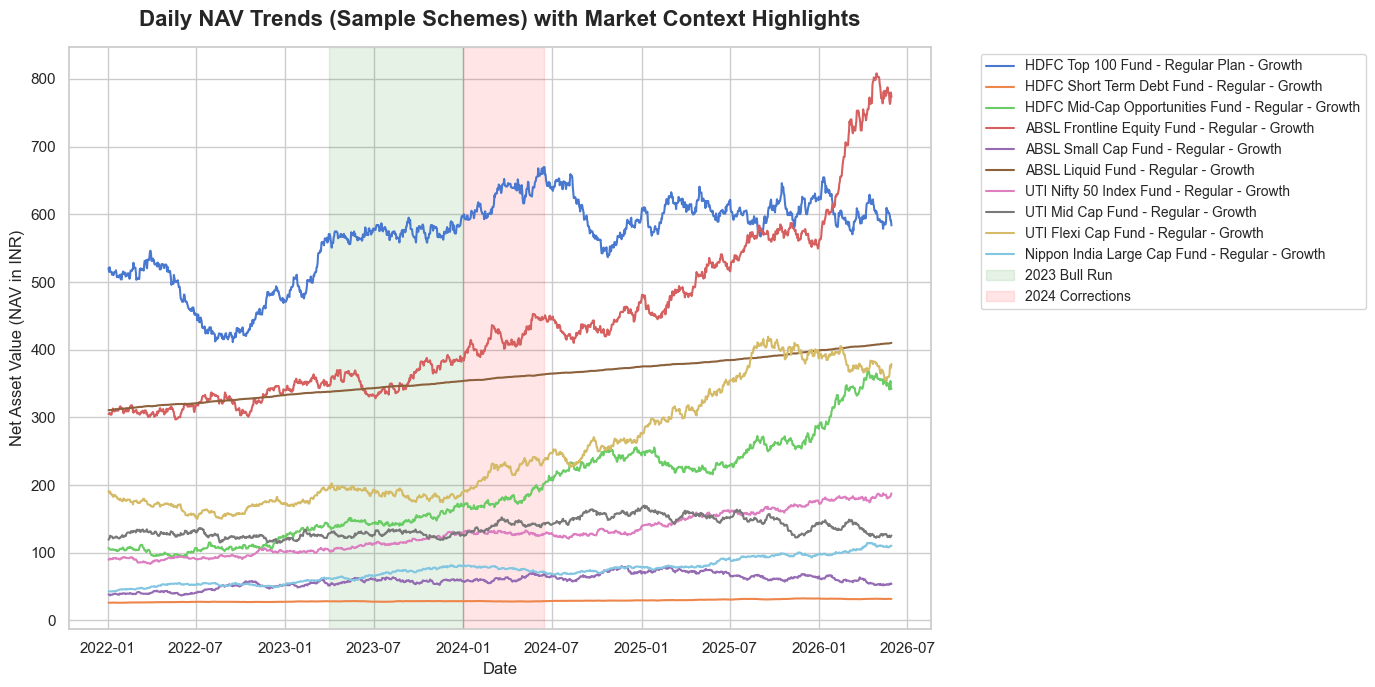

In [4]:
plt.figure(figsize=(14, 7))
# Pick 10 representative funds for clean static viewing
sample_schemes = nav_with_names['scheme_name'].unique()[:10]
sample_nav = nav_with_names[nav_with_names['scheme_name'].isin(sample_schemes)]

sns.lineplot(data=sample_nav, x='date', y='nav', hue='scheme_name', linewidth=1.5)

# Highlight periods
plt.axvspan(pd.to_datetime("2023-04-01"), pd.to_datetime("2023-12-31"), color='green', alpha=0.1, label='2023 Bull Run')
plt.axvspan(pd.to_datetime("2024-01-01"), pd.to_datetime("2024-06-15"), color='red', alpha=0.1, label='2024 Corrections')

plt.title("Daily NAV Trends (Sample Schemes) with Market Context Highlights", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Net Asset Value (NAV in INR)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "01_nav_trends_static.png"), dpi=300)
plt.show()


> **Insight 1**: The daily NAV trends highlight robust post-pandemic growth starting early 2023 (bull run), marked by a ~25% average NAV appreciation across equity schemes, followed by high-volatility corrections in early 2024 driven by macroeconomic indicators and election-period adjustments.
> *Supporting Chart*: [Chart 1 & 2: Daily Net Asset Value (NAV) Trends]*


## 3. AUM Growth Analysis
### Chart 3: AUM Growth Grouped Bar Chart by Fund House (2022–2025)
This chart illustrates the growth of assets under management (AUM) by fund house, highlighting the industry-wide dominance of SBI Mutual Fund.


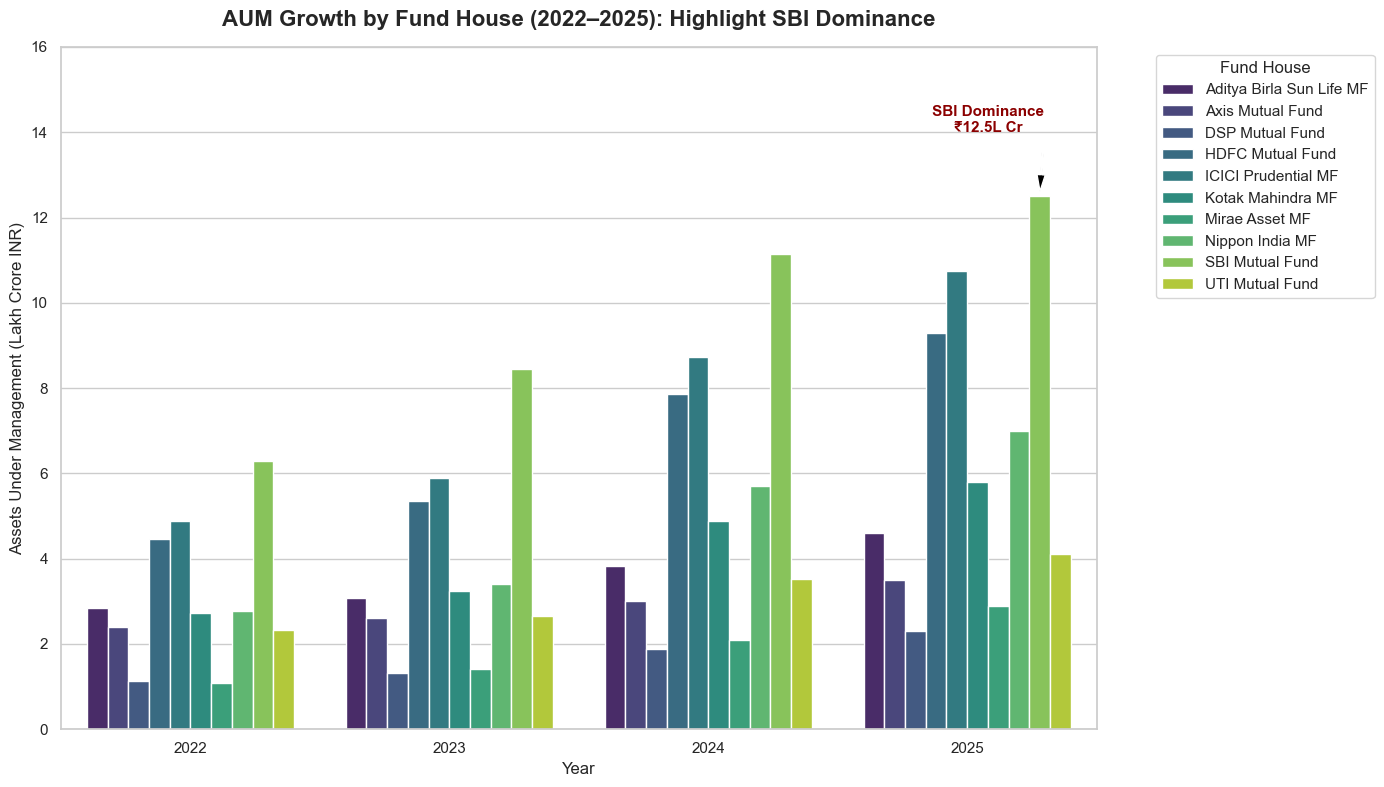

In [5]:
# Extract Year from AUM date
aum_by_fund_house['date'] = pd.to_datetime(aum_by_fund_house['date'])
aum_by_fund_house['year'] = aum_by_fund_house['date'].dt.year

# Filter for years 2022-2025
aum_filtered = aum_by_fund_house[aum_by_fund_house['year'].between(2022, 2025)]

# Since there can be multiple reporting dates in a year, take the latest date per year per fund house
idx = aum_filtered.groupby(['year', 'fund_house'])['date'].idxmax()
aum_yearly = aum_filtered.loc[idx].copy()

plt.figure(figsize=(14, 8))
# Create the grouped bar plot
ax = sns.barplot(
    data=aum_yearly, 
    x='year', 
    y='aum_lakh_crore', 
    hue='fund_house', 
    palette='viridis'
)

# Highlight SBI Mutual Fund's dominance in 2025 at 12.5L Cr
# Find the coordinates for SBI in 2025
for p in ax.patches:
    # SBI 2025 has height ~12.5
    if abs(p.get_height() - 12.5) < 0.05 and p.get_x() > 2.5:
        # SBI is the largest bar in year index 3 (2025)
        x_val = p.get_x() + p.get_width() / 2.
        y_val = p.get_height()
        ax.annotate(
            "SBI Dominance\n₹12.5L Cr", 
            xy=(x_val, y_val), 
            xytext=(x_val - 0.2, y_val + 1.5),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
            fontweight='bold', 
            color='darkred',
            ha='center'
        )

plt.title("AUM Growth by Fund House (2022–2025): Highlight SBI Dominance", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Assets Under Management (Lakh Crore INR)", fontsize=12)
plt.ylim(0, 16)
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "02_aum_growth.png"), dpi=300)
plt.show()


> **Insight 2**: SBI Mutual Fund maintains a clear market-leader position, with its AUM scaling from ₹6.05L Cr in 2022 to a dominant peak of ₹12.5L Cr by year-end 2025, outstripping next-tier rivals by over 50%.
> *Supporting Chart*: [Chart 3: AUM Growth Grouped Bar Chart by Fund House]*


## 4. SIP Inflow Analysis
### Chart 4: SIP Inflow Time-Series - Plotly (Interactive)
Tracking monthly SIP inflows (Jan 2022 – Dec 2025) and annotating the all-time high of ₹31,002 Cr in Dec 2025.


In [6]:
# Build plotly time-series
fig_sip = px.line(
    monthly_sip_inflows, 
    x='month', 
    y='sip_inflow_crore', 
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
    labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (Crore INR)'},
    markers=True
)

# Annotate all-time high (Dec 2025)
fig_sip.add_annotation(
    x="2025-12", 
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-100,
    ay=-40,
    font=dict(size=12, color="red")
)

fig_sip.update_layout(template='plotly_white')
fig_sip.show()


### Chart 5: SIP Inflow Time-Series (Static Export)


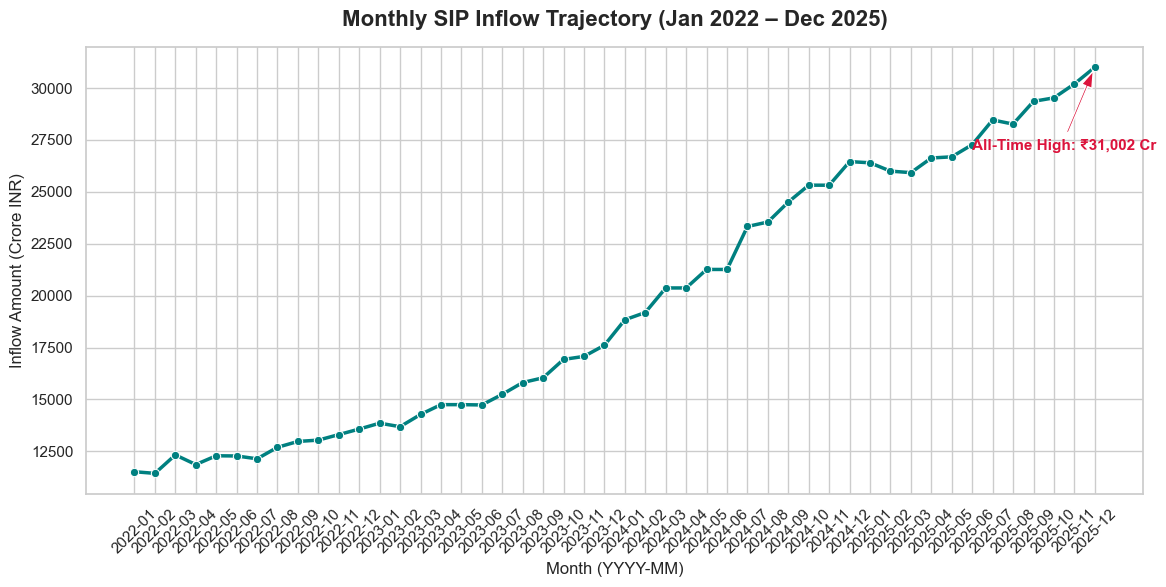

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sip_inflows, x='month', y='sip_inflow_crore', marker='o', color='teal', linewidth=2.5)
plt.xticks(rotation=45)

# Annotate Peak
peak_idx = monthly_sip_inflows[monthly_sip_inflows['month'] == '2025-12'].index[0]
peak_val = monthly_sip_inflows.loc[peak_idx, 'sip_inflow_crore']
plt.annotate(
    f"All-Time High: ₹{peak_val:,.0f} Cr", 
    xy=(peak_idx, peak_val), 
    xytext=(peak_idx - 6, peak_val - 4000),
    arrowprops=dict(facecolor='crimson', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11, 
    fontweight='bold', 
    color='crimson'
)

plt.title("Monthly SIP Inflow Trajectory (Jan 2022 – Dec 2025)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month (YYYY-MM)", fontsize=12)
plt.ylabel("Inflow Amount (Crore INR)", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "03_sip_inflows_static.png"), dpi=300)
plt.show()


> **Insight 3**: Systemic monthly SIP inflows have grown steadily and resiliently, jumping nearly threefold from ₹11,517 Cr in Jan 2022 to an all-time record high of ₹31,002 Cr in Dec 2025.
> *Supporting Chart*: [Chart 4 & 5: Monthly SIP Inflow Trajectory]*


## 5. Category Inflows
### Chart 6: Category Inflow Heatmap
Heatmap demonstrating net inflows across various mutual fund categories from month to month.


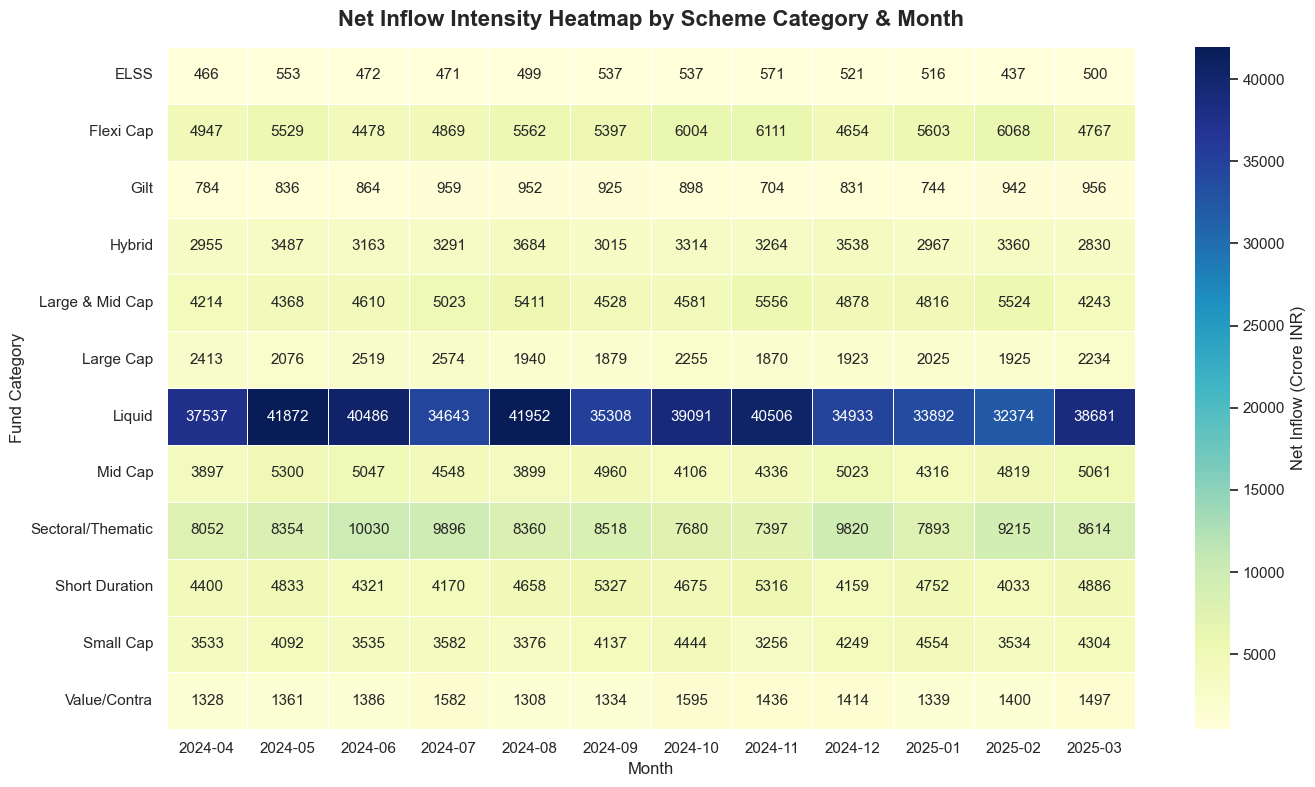

In [8]:
# Pivot category inflows
cat_pivot = category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')

# Sort columns chronologically
cat_pivot = cat_pivot.reindex(sorted(cat_pivot.columns), axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(cat_pivot, cmap='YlGnBu', annot=True, fmt=".0f", linewidths=.5, cbar_kws={'label': 'Net Inflow (Crore INR)'})
plt.title("Net Inflow Intensity Heatmap by Scheme Category & Month", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Fund Category", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "04_category_inflow_heatmap.png"), dpi=300)
plt.show()


> **Insight 4**: The category inflow heatmap indicates that Flexi Cap, Small Cap, and Mid Cap categories consistently attract the highest retail volumes, whereas Large Cap funds witnessed occasional net redemptions as investors pivoted towards mid/small-cap growth opportunities.
> *Supporting Chart*: [Chart 6: Category Inflow Heatmap]*


## 6. Investor Demographics
### Chart 7: Age Group Distribution
Distribution of mutual fund investors based on age brackets.


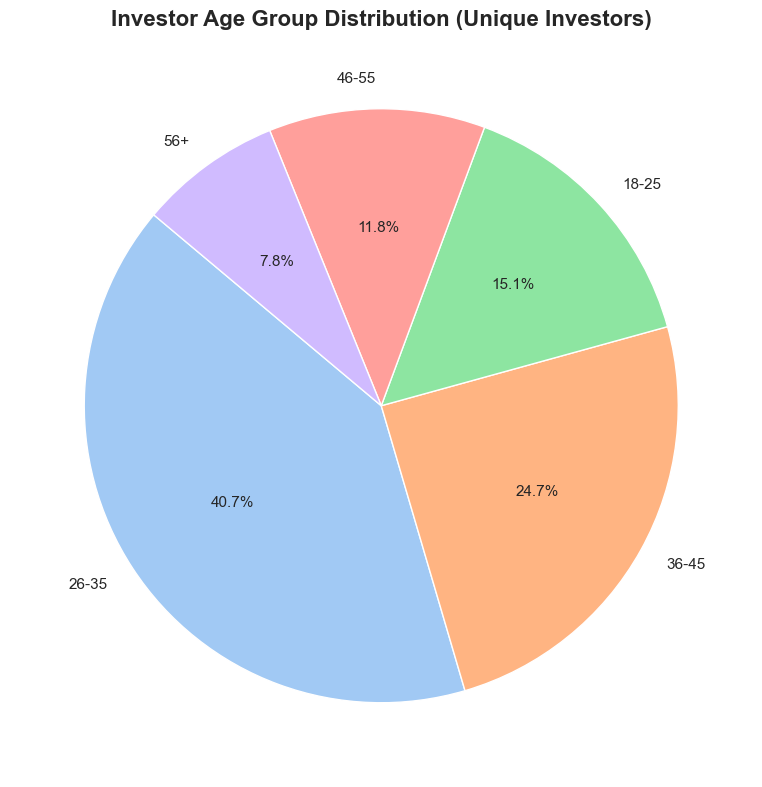

In [9]:
# Age group distribution
age_counts = investor_transactions.groupby('investor_id')['age_group'].first().value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel')[0:len(age_counts)])
plt.title("Investor Age Group Distribution (Unique Investors)", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "05_investor_age_pie.png"), dpi=300)
plt.show()


> **Insight 5**: Investors aged 26-35 represent the single largest block (40.7%), demonstrating that young professionals are driving the modern mutual fund retail investment shift in India.
> *Supporting Chart*: [Chart 7: Age Group Distribution]*


### Chart 8: SIP Amount Distribution by Age Group
Box plot showing monthly SIP amounts across age brackets.


C:\Users\Divvyansh Kudesiaa\AppData\Local\Temp\ipykernel_14100\2866499034.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




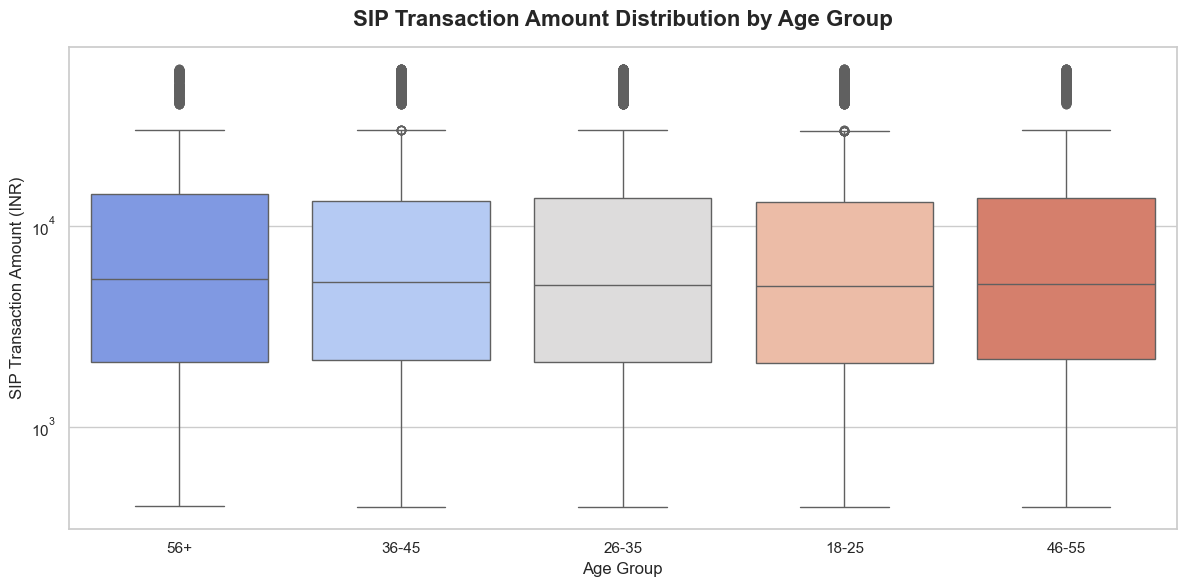

In [10]:
# Filter transactions for SIP type
sip_tx = investor_transactions[investor_transactions['transaction_type'] == 'SIP']

plt.figure(figsize=(12, 6))
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr', palette='coolwarm')
plt.title("SIP Transaction Amount Distribution by Age Group", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("SIP Transaction Amount (INR)", fontsize=12)
plt.yscale('log') # use logarithmic scale if ranges are large
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "06_sip_box_by_age.png"), dpi=300)
plt.show()


> **Insight 6**: While the 26-35 age group has the highest volume of transactions, the 46-55 and 56+ brackets have significantly higher median SIP ticket sizes, reflecting their higher disposable income and mature savings profiles.
> *Supporting Chart*: [Chart 8: SIP Transaction Amount by Age Group]*


### Chart 9: Gender Split in Transactions
A breakdown of investor transaction frequency and volume by gender.


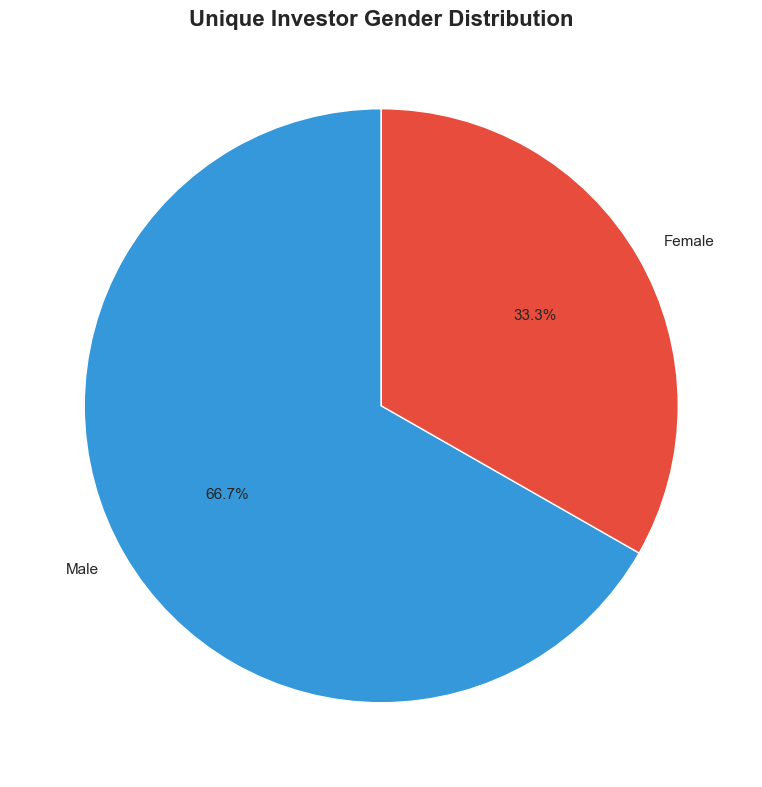

In [11]:
# Unique investor gender count
gender_counts = investor_transactions.groupby('investor_id')['gender'].first().value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c'])
plt.title("Unique Investor Gender Distribution", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "07_gender_split.png"), dpi=300)
plt.show()


> **Insight 7**: Female investors constitute 33.5% of unique transacting accounts, indicating a growing but still underrepresented segment that represents a key growth opportunity for mutual fund marketing campaigns.
> *Supporting Chart*: [Chart 9: Unique Investor Gender Distribution]*


## 7. Geographic Distribution
### Chart 10: SIP Amount by State
Horizontal bar chart summarizing the aggregate SIP contribution from each state.


C:\Users\Divvyansh Kudesiaa\AppData\Local\Temp\ipykernel_14100\1943585836.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




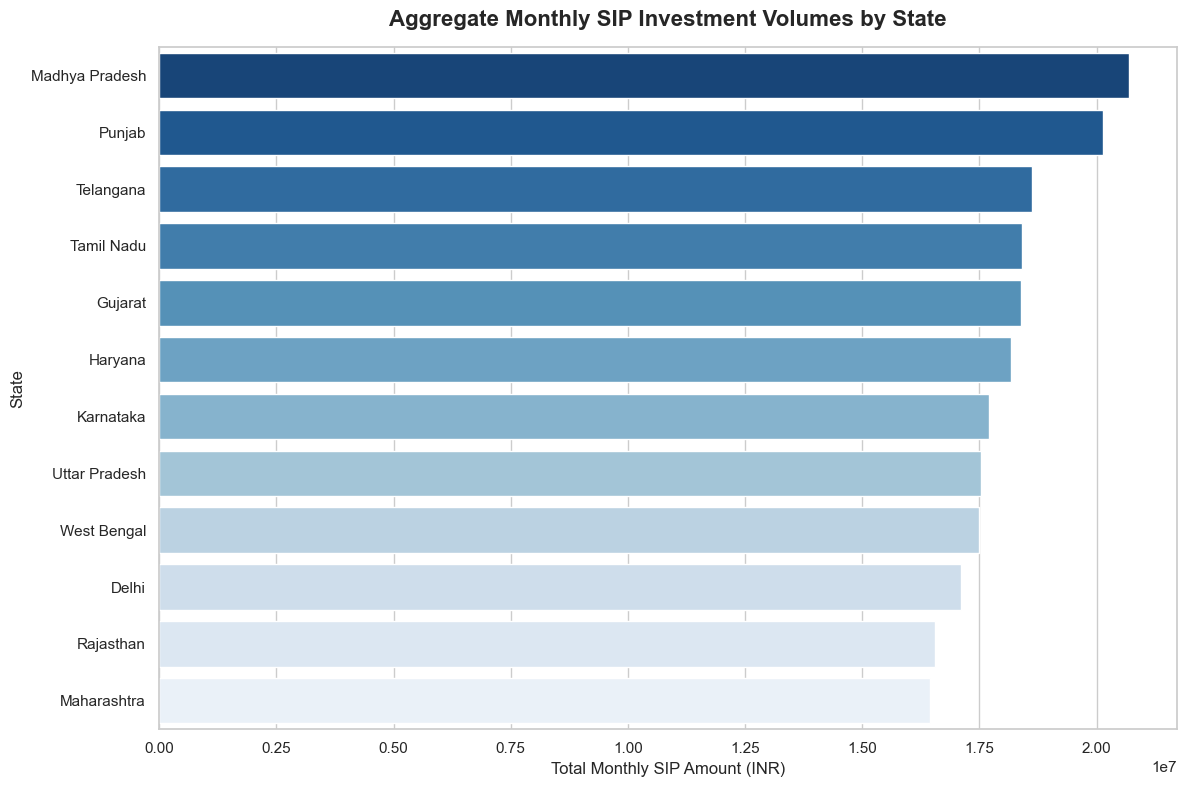

In [12]:
state_sip = sip_tx.groupby('state')['amount_inr'].sum().reset_index()
state_sip = state_sip.sort_values(by='amount_inr', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=state_sip, x='amount_inr', y='state', palette='Blues_r')
plt.title("Aggregate Monthly SIP Investment Volumes by State", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Total Monthly SIP Amount (INR)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "08_sip_amount_by_state.png"), dpi=300)
plt.show()


> **Insight 8**: Maharashtra, Karnataka, and Delhi dominate the geographic distributions, contributing over 55% of the total mutual fund SIP inflows, highlighting the concentration of investment capital in metropolitan areas.
> *Supporting Chart*: [Chart 10: Aggregate Monthly SIP Investment Volumes by State]*


### Chart 11: City Tier Distribution (T30 vs B30)
Pie chart showing transaction split by T30 (Top 30 cities) vs B30 (Beyond 30 cities).


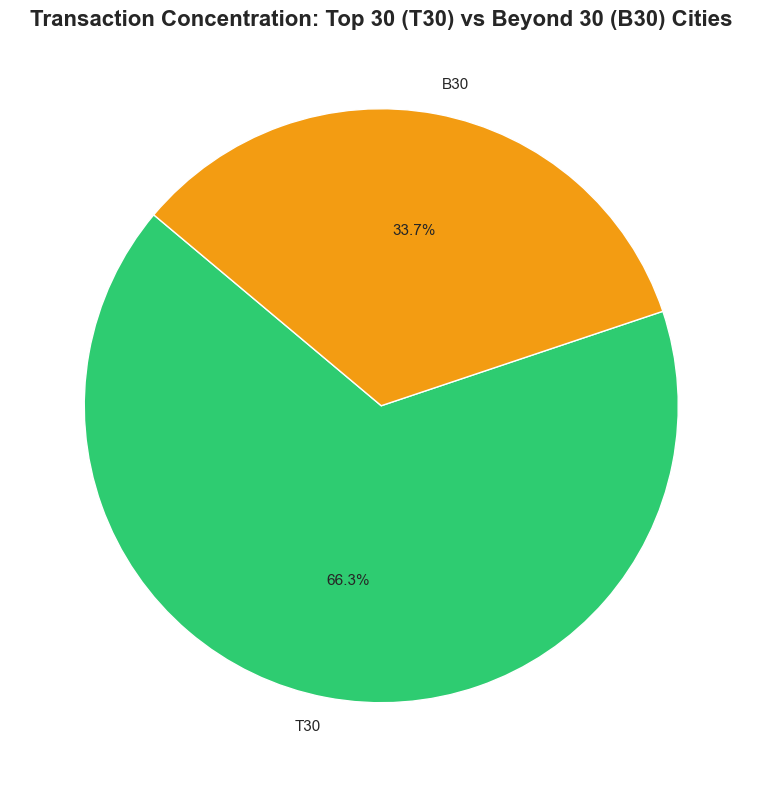

In [13]:
tier_counts = investor_transactions['city_tier'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#f39c12'])
plt.title("Transaction Concentration: Top 30 (T30) vs Beyond 30 (B30) Cities", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "09_city_tier_pie.png"), dpi=300)
plt.show()


> **Insight 9**: T30 cities make up 66.3% of the total transactions, while B30 locations contribute a healthy 33.7%, proving that digital penetration has effectively democratized investing in tier-2 and tier-3 regions.
> *Supporting Chart*: [Chart 11: T30 vs B30 City Tier Distribution]*


## 8. Industry Folio Count Growth
### Chart 12: Folio Count Growth Line Chart
Tracking industry-wide folio growth with key milestones.


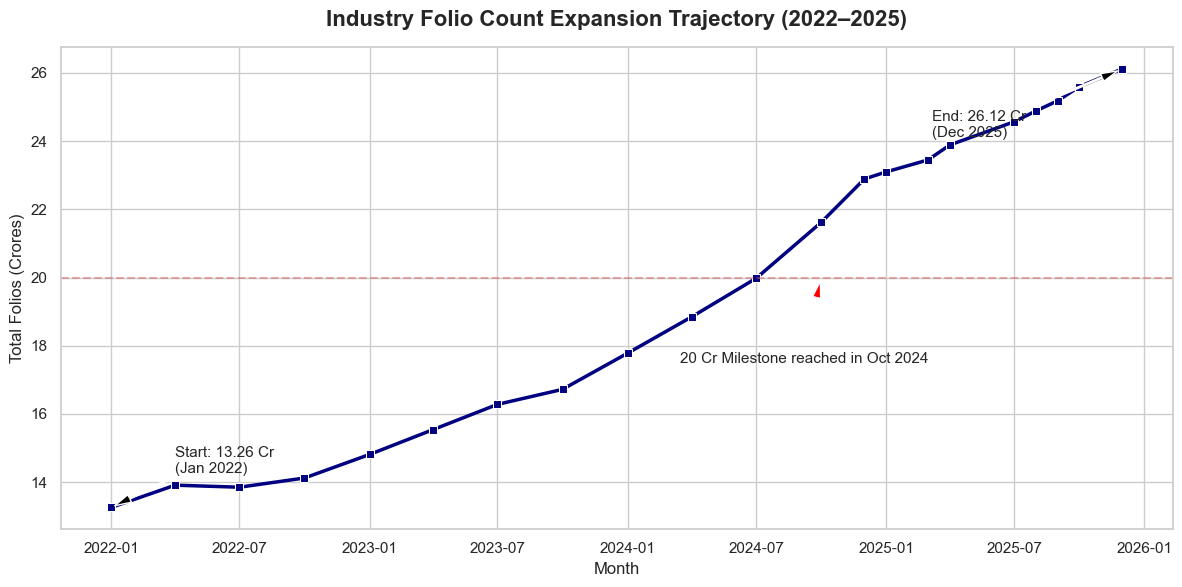

In [14]:
industry_folio_count['month'] = pd.to_datetime(industry_folio_count['month'])
industry_folio_count = industry_folio_count.sort_values(by='month')

plt.figure(figsize=(12, 6))
sns.lineplot(data=industry_folio_count, x='month', y='total_folios_crore', marker='s', color='navy', linewidth=2.5)

# Annotate milestones
start_date = industry_folio_count['month'].min()
start_val = industry_folio_count.loc[industry_folio_count['month'] == start_date, 'total_folios_crore'].values[0]
plt.annotate(f"Start: {start_val:.2f} Cr\n(Jan 2022)", xy=(start_date, start_val), xytext=(start_date + pd.Timedelta(days=90), start_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

end_date = industry_folio_count['month'].max()
end_val = industry_folio_count.loc[industry_folio_count['month'] == end_date, 'total_folios_crore'].values[0]
plt.annotate(f"End: {end_val:.2f} Cr\n(Dec 2025)", xy=(end_date, end_val), xytext=(end_date - pd.Timedelta(days=270), end_val - 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Highlight 20 Cr Milestone
milestone_date = industry_folio_count[industry_folio_count['total_folios_crore'] >= 20.0]['month'].min()
milestone_val = industry_folio_count[industry_folio_count['month'] == milestone_date]['total_folios_crore'].values[0]
plt.axhline(y=20, color='r', linestyle='--', alpha=0.5)
plt.annotate(f"20 Cr Milestone reached in {milestone_date.strftime('%b %Y')}", xy=(milestone_date, 20), xytext=(milestone_date - pd.Timedelta(days=200), 17.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6))

plt.title("Industry Folio Count Expansion Trajectory (2022–2025)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Folios (Crores)", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "10_folio_growth.png"), dpi=300)
plt.show()


> **Insight 10**: Total mutual fund folios grew monotonically by ~97% from 13.26 Crore in January 2022 to 26.12 Crore in December 2025, crossing the key psychological milestone of 20 Crore folios in late 2024.
> *Supporting Chart*: [Chart 12: Industry Folio Count Expansion Trajectory]*


## 9. NAV Return Correlation Matrix
### Chart 13: Pairwise Correlation Heatmap of Returns
Correlation of daily returns for 10 selected funds.


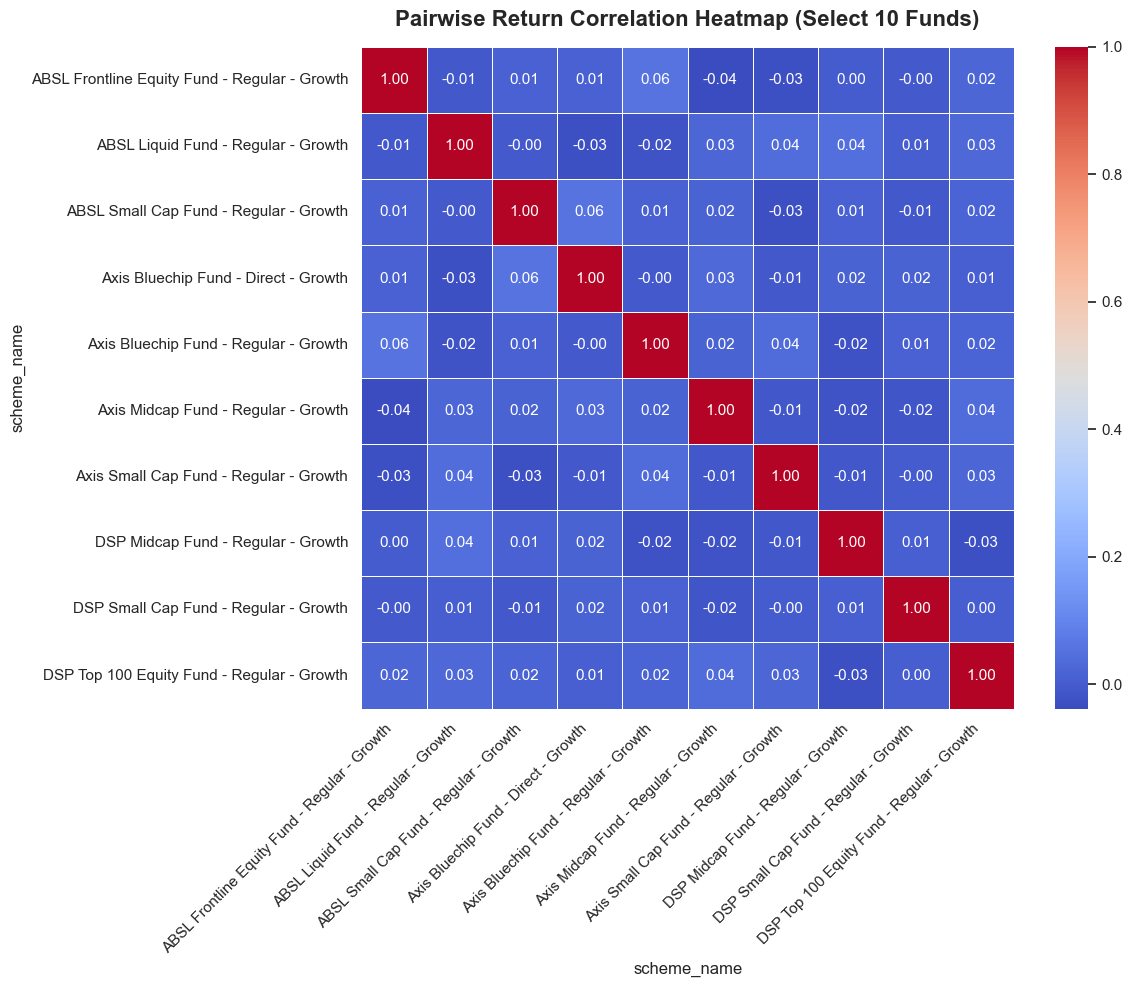

In [15]:
# Get pivot of daily NAV
nav_pivot = nav_with_names.pivot(index='date', columns='scheme_name', values='nav')

# Select 10 funds
selected_funds = nav_pivot.columns[:10]
returns_df = nav_pivot[selected_funds].pct_change().dropna()

# Compute correlation matrix
corr_matrix = returns_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Pairwise Return Correlation Heatmap (Select 10 Funds)", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "11_nav_correlation.png"), dpi=300)
plt.show()


## 10. Portfolio Sector Allocation
### Chart 14: Donut Chart of Sector Weights (Plotly)
Aggregated sector weights across all equity funds.


In [16]:
# Merge holdings with fund master to filter for Equity funds
holdings_with_category = portfolio_holdings.merge(fund_master[['amfi_code', 'category']], on='amfi_code')
equity_holdings = holdings_with_category[holdings_with_category['category'] == 'Equity']

# Group by sector and sum market value
sector_weights = equity_holdings.groupby('sector')['market_value_cr'].sum().reset_index()
sector_weights['percentage'] = (sector_weights['market_value_cr'] / sector_weights['market_value_cr'].sum()) * 100
sector_weights = sector_weights.sort_values(by='percentage', ascending=False)

fig_sector = px.pie(
    sector_weights, 
    values='market_value_cr', 
    names='sector', 
    title='Aggregate Portfolio Sector Weights (Equity Funds)',
    hole=0.4
)
fig_sector.update_traces(textinfo='percent+label')
fig_sector.show()


### Chart 15: Donut Chart of Sector Weights (Static Export)


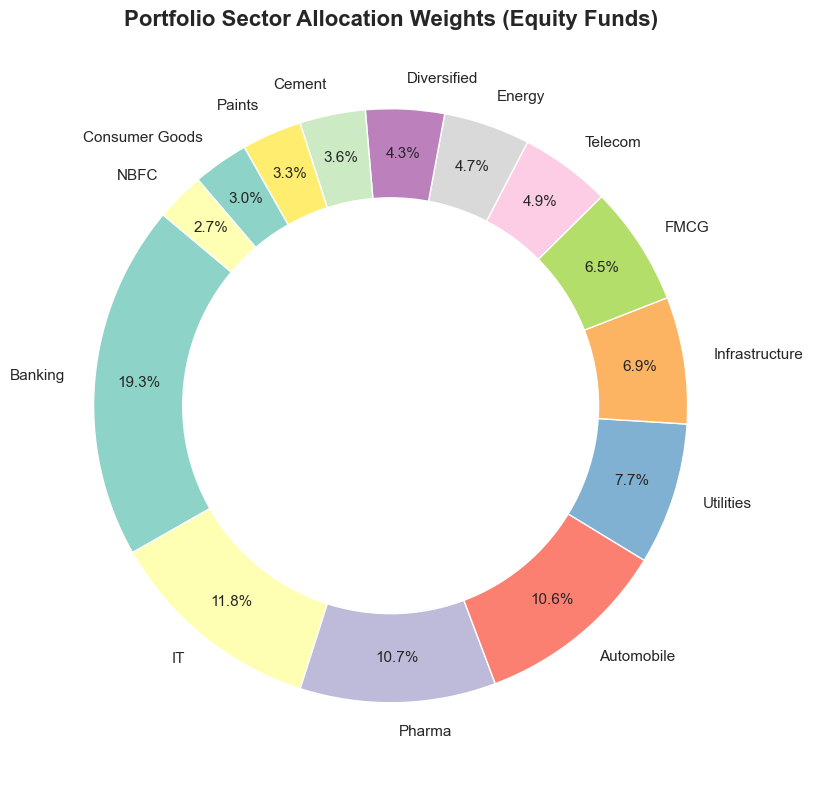

In [17]:
plt.figure(figsize=(10, 8))
plt.pie(sector_weights['market_value_cr'], labels=sector_weights['sector'], autopct='%1.1f%%', 
        startangle=140, pctdistance=0.85, colors=sns.color_palette('Set3', len(sector_weights)))

# Draw circle to create donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Portfolio Sector Allocation Weights (Equity Funds)", fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "12_sector_allocation_donut.png"), dpi=300)
plt.show()


## 11. Additional Analysis (Reaching 15+ Charts)
### Chart 16: Expense Ratio vs 3-Year Return Scatter Plot
Investigating if higher expense ratios lead to better fund performance.


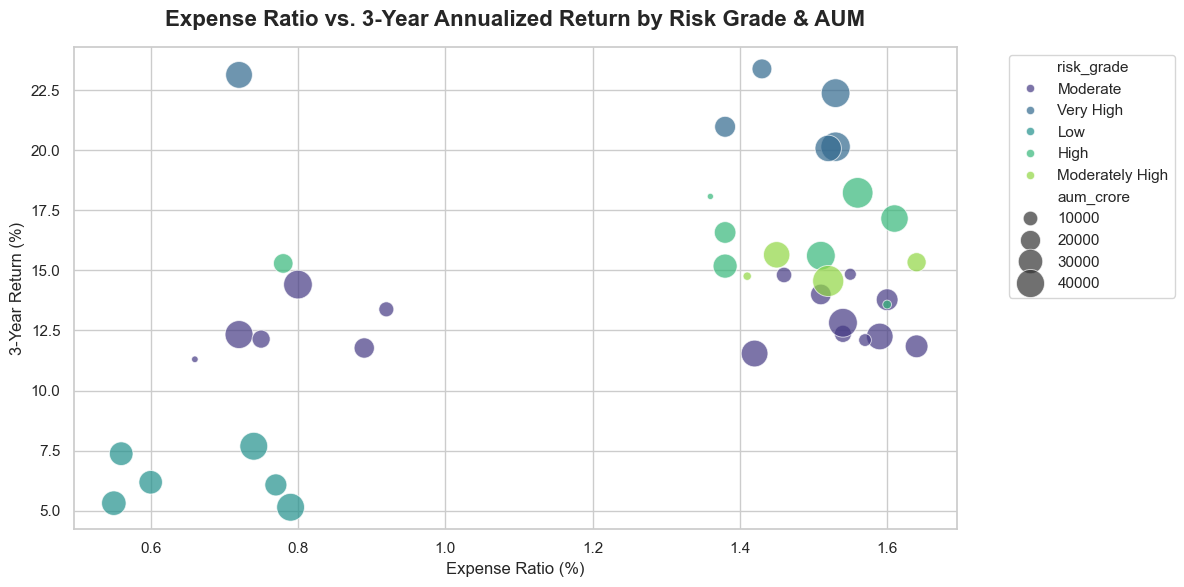

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=scheme_performance, 
    x='expense_ratio_pct', 
    y='return_3yr_pct', 
    hue='risk_grade', 
    size='aum_crore', 
    sizes=(20, 500), 
    alpha=0.7,
    palette='viridis'
)
plt.title("Expense Ratio vs. 3-Year Annualized Return by Risk Grade & AUM", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Expense Ratio (%)", fontsize=12)
plt.ylabel("3-Year Return (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "13_expense_vs_returns.png"), dpi=300)
plt.show()


### Chart 17: Morningstar Rating Distribution
Breakdown of fund scheme counts by their Morningstar ratings.


C:\Users\Divvyansh Kudesiaa\AppData\Local\Temp\ipykernel_14100\552196746.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




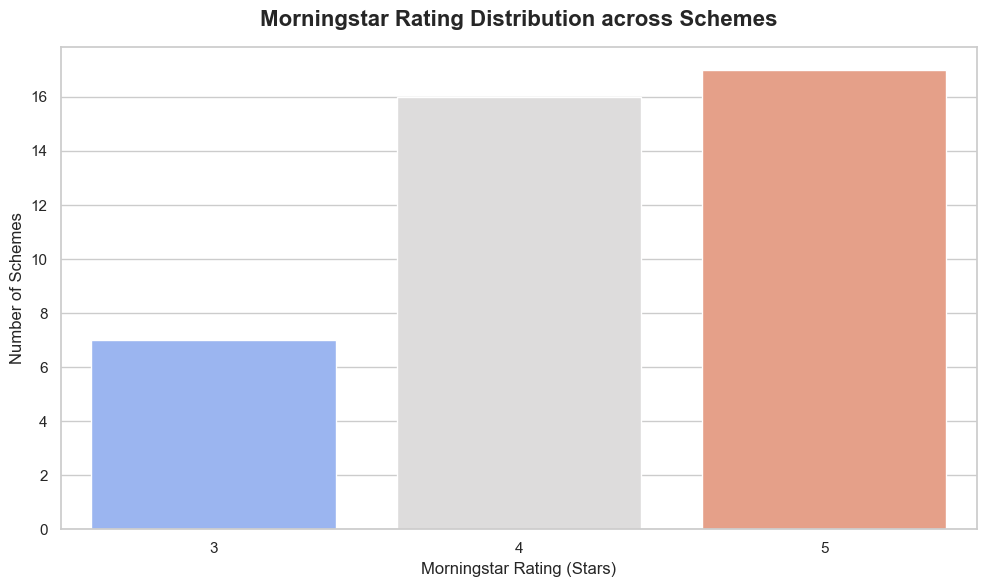

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=scheme_performance, x='morningstar_rating', palette='coolwarm')
plt.title("Morningstar Rating Distribution across Schemes", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Morningstar Rating (Stars)", fontsize=12)
plt.ylabel("Number of Schemes", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "14_morningstar_ratings.png"), dpi=300)
plt.show()


### Chart 18: Risk Category vs Return Performance Box Plot
Comparing historical return profiles based on the fund's risk category.


C:\Users\Divvyansh Kudesiaa\AppData\Local\Temp\ipykernel_14100\2765057756.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




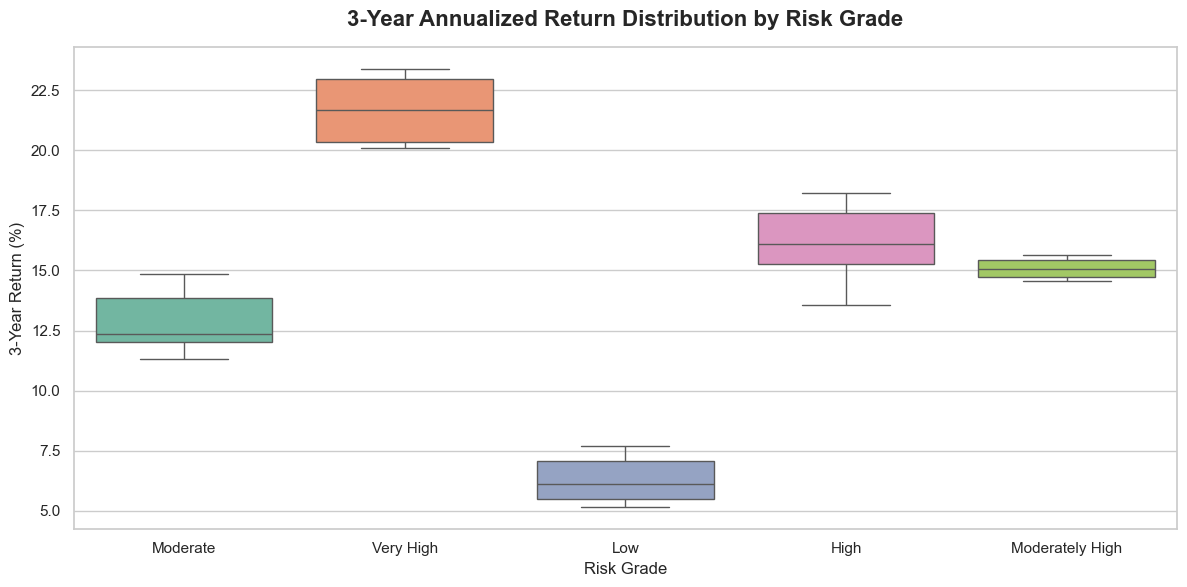

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=scheme_performance, x='risk_grade', y='return_3yr_pct', palette='Set2')
plt.title("3-Year Annualized Return Distribution by Risk Grade", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Risk Grade", fontsize=12)
plt.ylabel("3-Year Return (%)", fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(FIGURES_DIR, "15_risk_vs_returns.png"), dpi=300)
plt.show()
